In [1]:
from swemnics.problems import SlopedBeachProblem
from swemnics import solvers as Solvers
from mpi4py import MPI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dolfinx import fem as fe
import pickle
import os

import pandas as pd
import seaborn as sns
from typing import Callable, Dict, List, Tuple, Any, Union

from plotting import plot_simulation_results, create_comparison_figure
from fourd_var import run_assimilation
from dca_utils import*

sns.set_palette("bright")
plt.style.use("mystyle1.mplstyle")


In [2]:
def get_true_signal(solver, problem_type, solver_params, obs_frequency=1):
    """
    Default values are sea level and 0 velocity
    """

    u_0 = solver.u_n  # full initial condition

    # Doesn't work for DG Case
    V = solver.V  # create full function space
    V_coords = (
        V.sub(0).collapse()[0].tabulate_dof_coordinates()
    )  # collapse to height function space

    stations = V_coords[::obs_frequency, :]

    solver.time_loop(
        solver_parameters=solver_params,
        stations=stations,
        plot_every=60,
        plot_name="SUPG_Tide",
        u_0=u_0,
        save_states=True,
        adjoint_method=True,
    )

    return solver

In [22]:
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

final_time = 7 * 24 * 60 * 60  # 7 days in seconds
dt = 900  # 30 minutes in seconds
problem_params = {
    'dt': dt,
    't': 0,
    't_final': final_time,
    'num_steps': int(np.ceil(final_time/dt)),
    'num_windows': final_time//14400,  # divide by 4 hours in seconds = 84 windows
    'fric_law': 'linear',    #friction law either quadratic or linear
    'sol_var': 'h'             #solution variable either h or hu
}

solver_params = {"rtol": 1e-5,
          "atol": 1e-6,
          "max_it":10,
          "relaxation_parameter":1.0,
          "ksp_type": "gmres",
          "pc_type": "ilu",
          "ksp_ErrorIfNotConverged": False
          }#,"pc_factor_mat_solver_type":"mumps"}


prob, solver = create_problem_solver(problem_params, "sloped_beach", true_signal=True, verbose=True)

obs_time_freq = 2



SWE TYPE full
Wetting drying activated 

Location of shoreline: 13800
setting initial condition
Fully conservative flux
Fully conservative flux
WD nonspherical

CF =  0.025
Adding DG boundary conditions weakly
Fully conservative flux


In [23]:
run_true = True

if run_true:
    assert problem_params['num_steps'] == int(np.ceil(problem_params['t_final']/problem_params['dt']))
    true_solver = get_true_signal(solver,'sloped_beach', solver_params,obs_time_freq)
    true_signal = np.array(true_solver.saved_states)

    with open(os.path.join('da_output','true_signal.pkl'), 'wb') as f:
        pickle.dump(true_signal, f)

calling time loop
plot every 60
nt 672
creating video
Interpolating bathymetry
Writing bathymetry
Wrote bathymetry
Time Step Number 0 Out of 672
0.0 % Complete
Residual norm 934.34838134481
linear solver convergence 3, iterations 11, resid norm 4.765887456175469e-10
dx_0 norm, 0.2787764019434424
Netwon Iteration 1: Correction norm 1.0000000000000002
Residual norm 0.23750424456042935
linear solver convergence 3, iterations 6, resid norm 3.9682645381354103e-10
Netwon Iteration 2: Correction norm 0.0001936054944518693
Residual norm 3.483368122143664e-05
linear solver convergence 3, iterations 0, resid norm 3.9682704596788665e-10
Netwon Iteration 3: Correction norm 0.0
Time Step Number 1 Out of 672
0.1488095238095238 % Complete
Residual norm 2912.1608915121205
linear solver convergence 3, iterations 12, resid norm 2.389692454442324e-10
dx_0 norm, 0.9439775998523148
Netwon Iteration 1: Correction norm 1.0
Residual norm 2.557031896914263
linear solver convergence 3, iterations 7, resid norm 

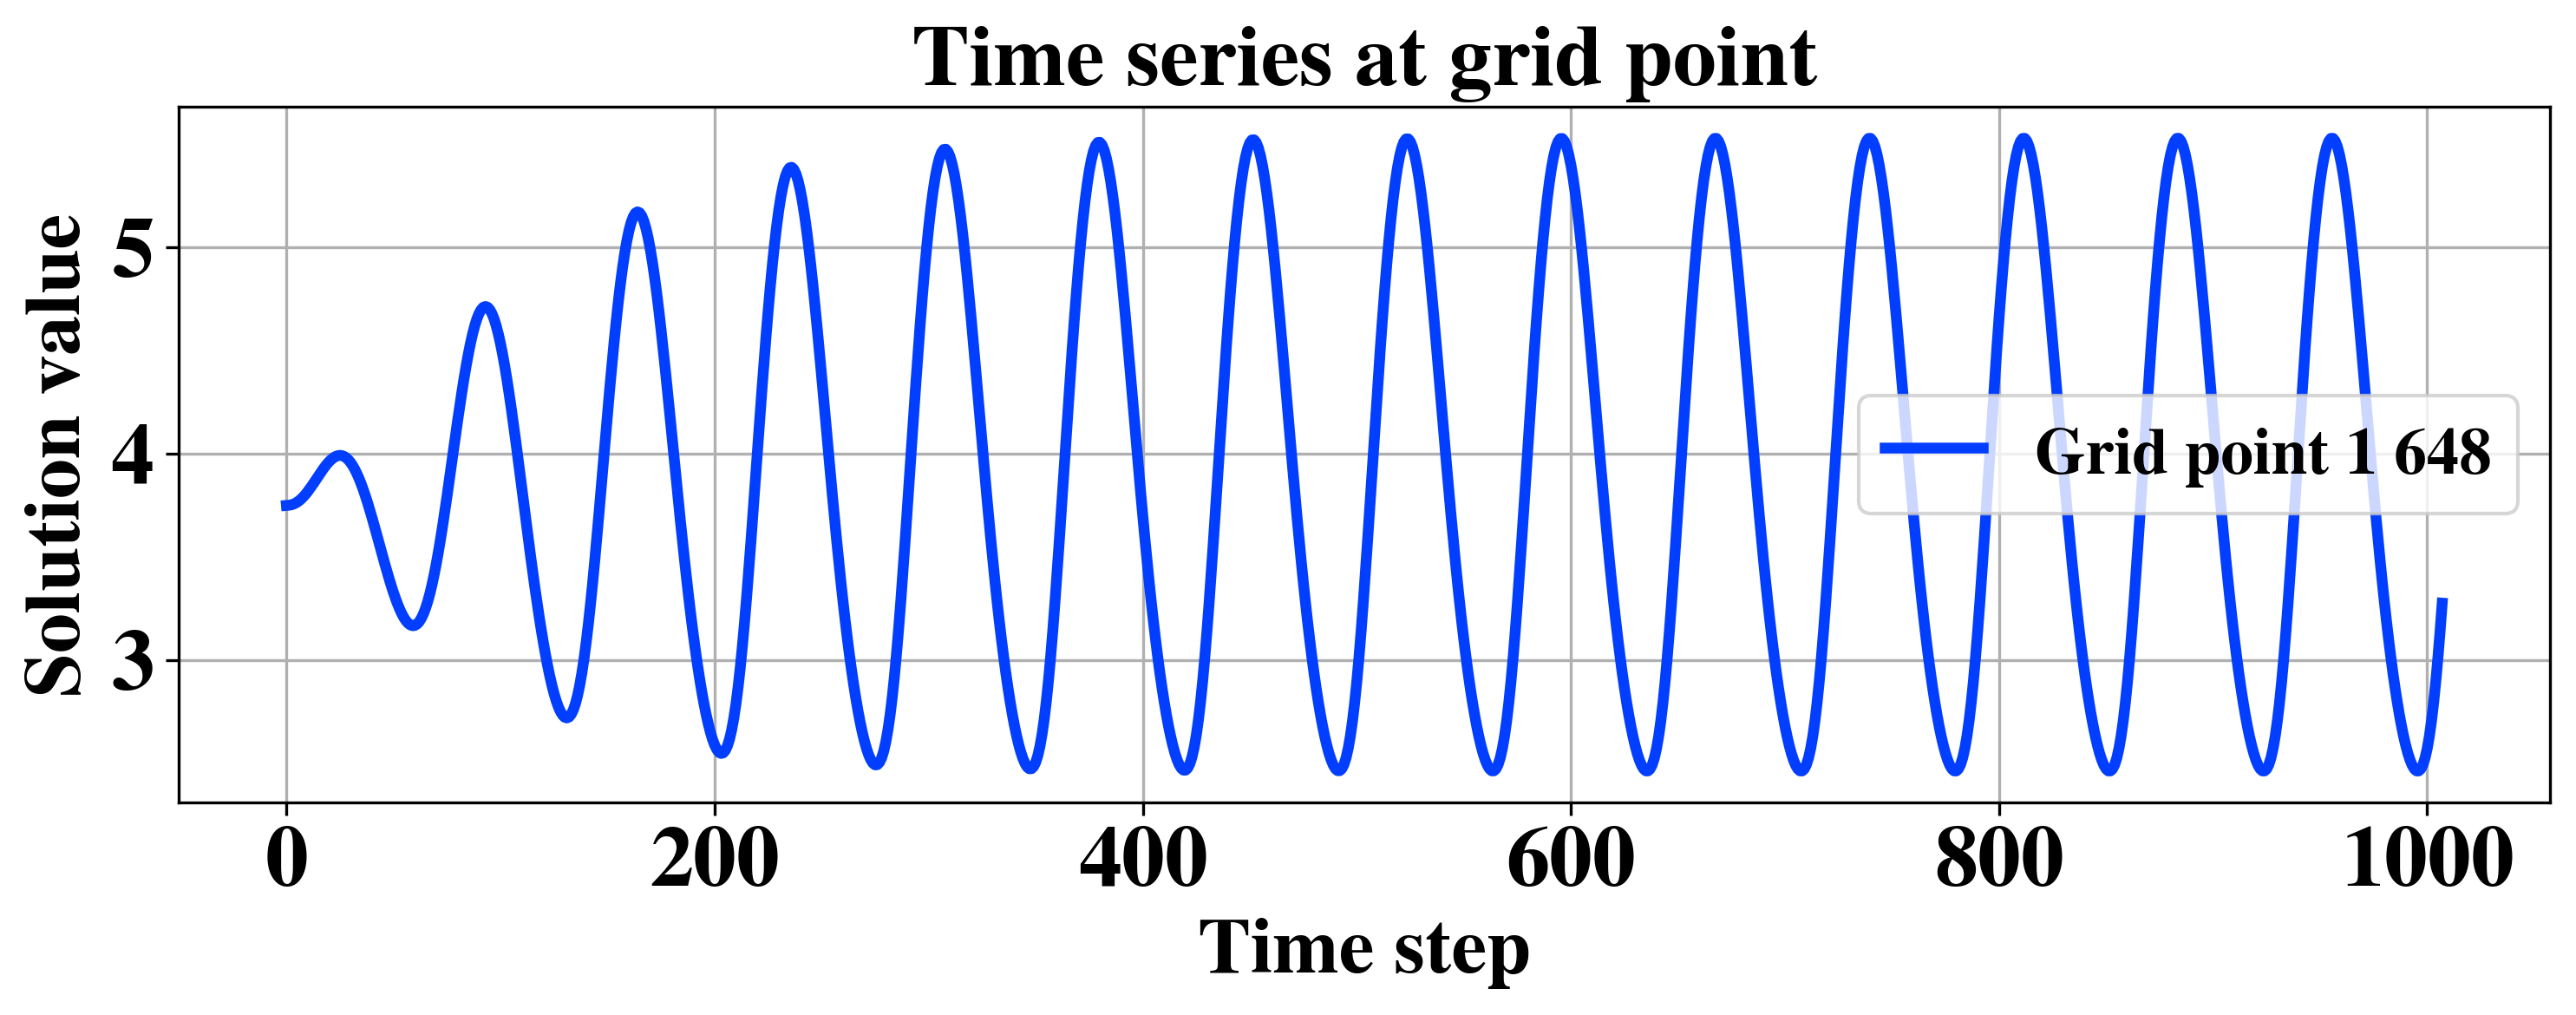

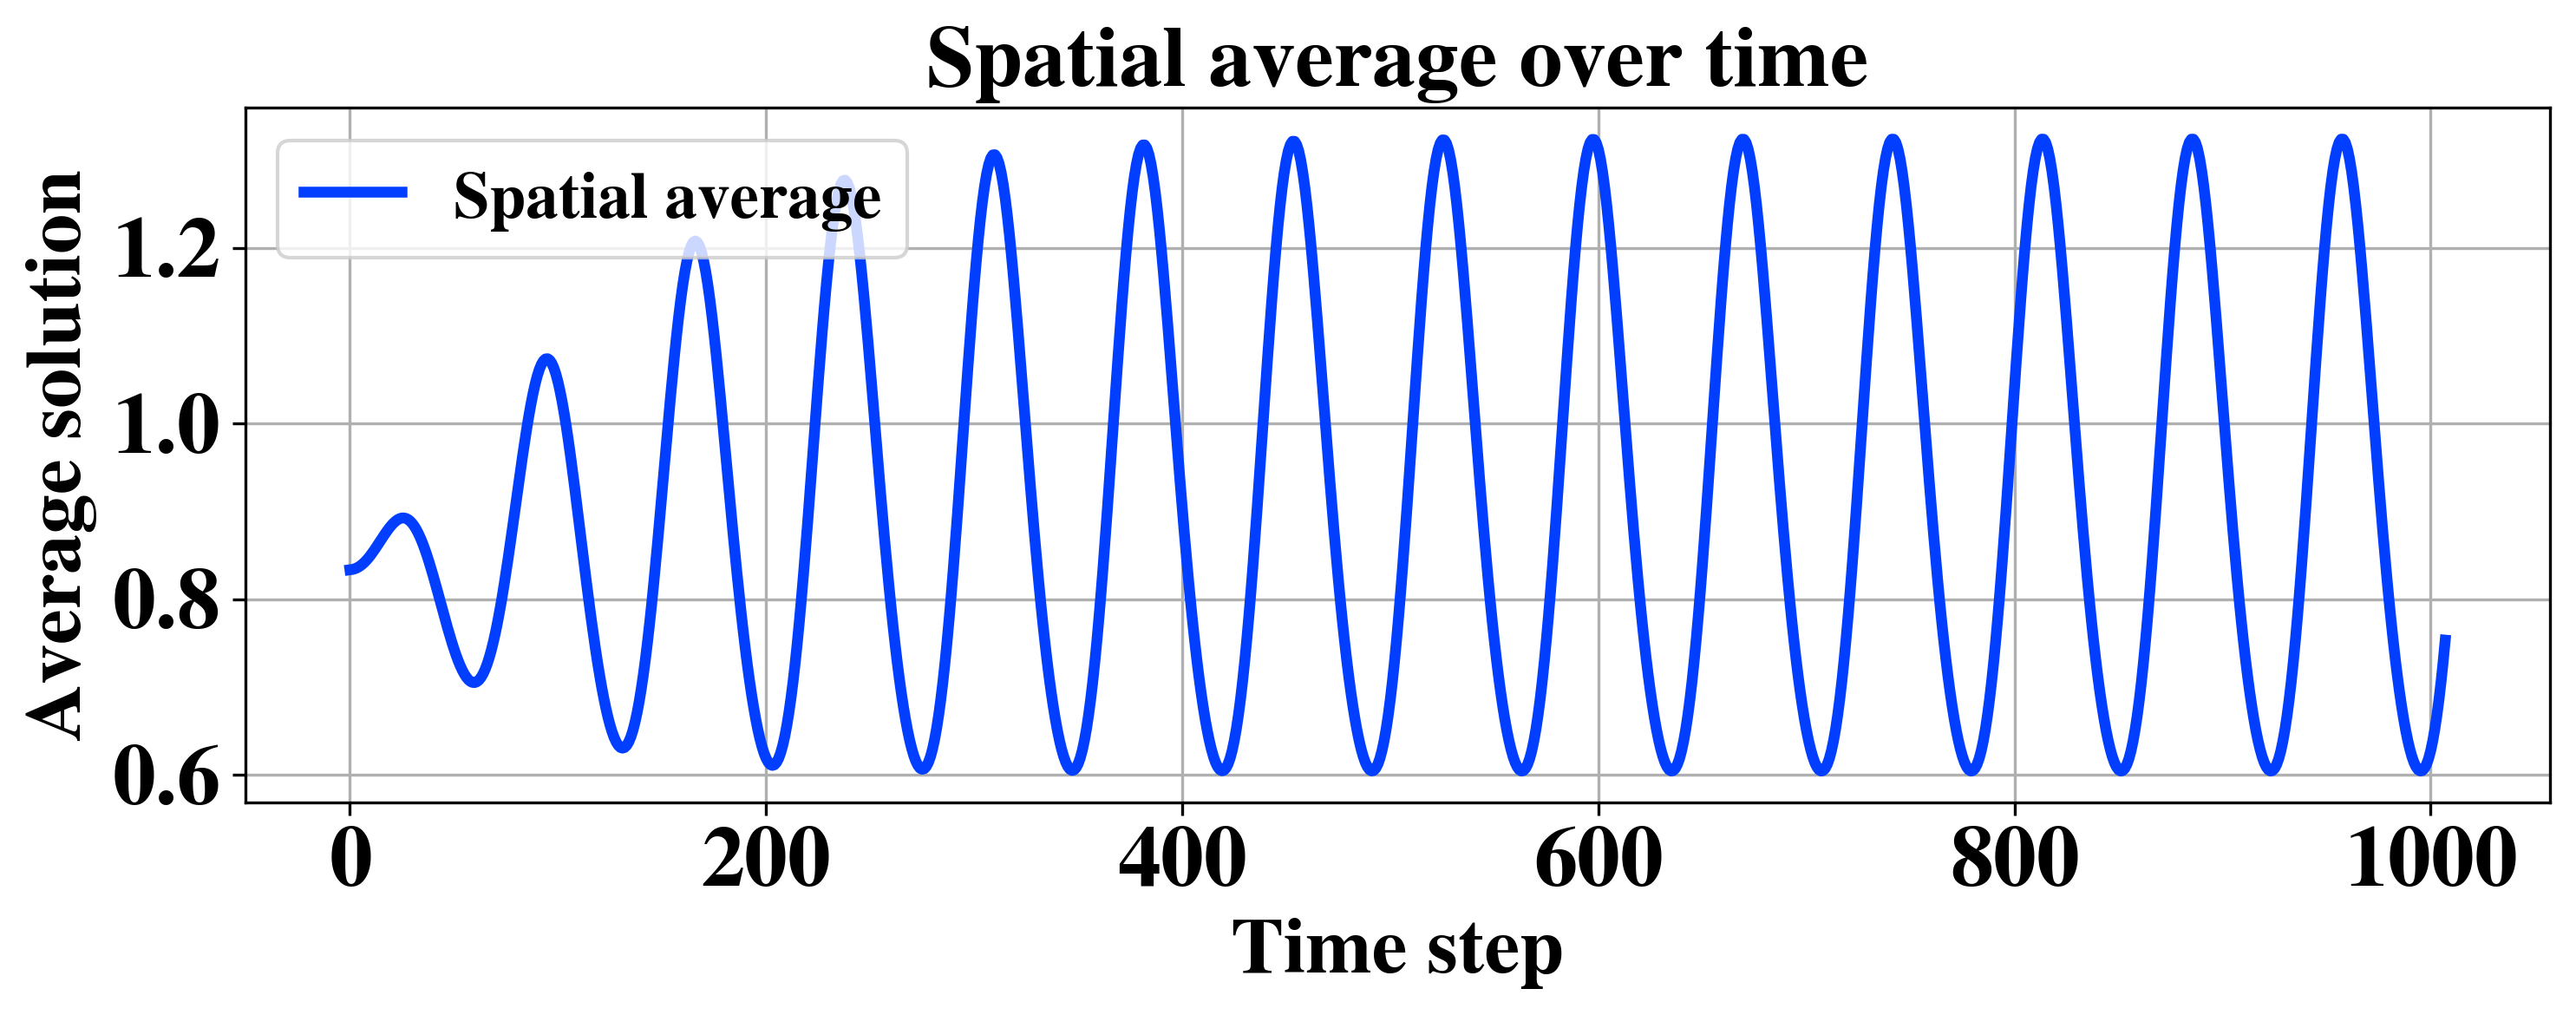

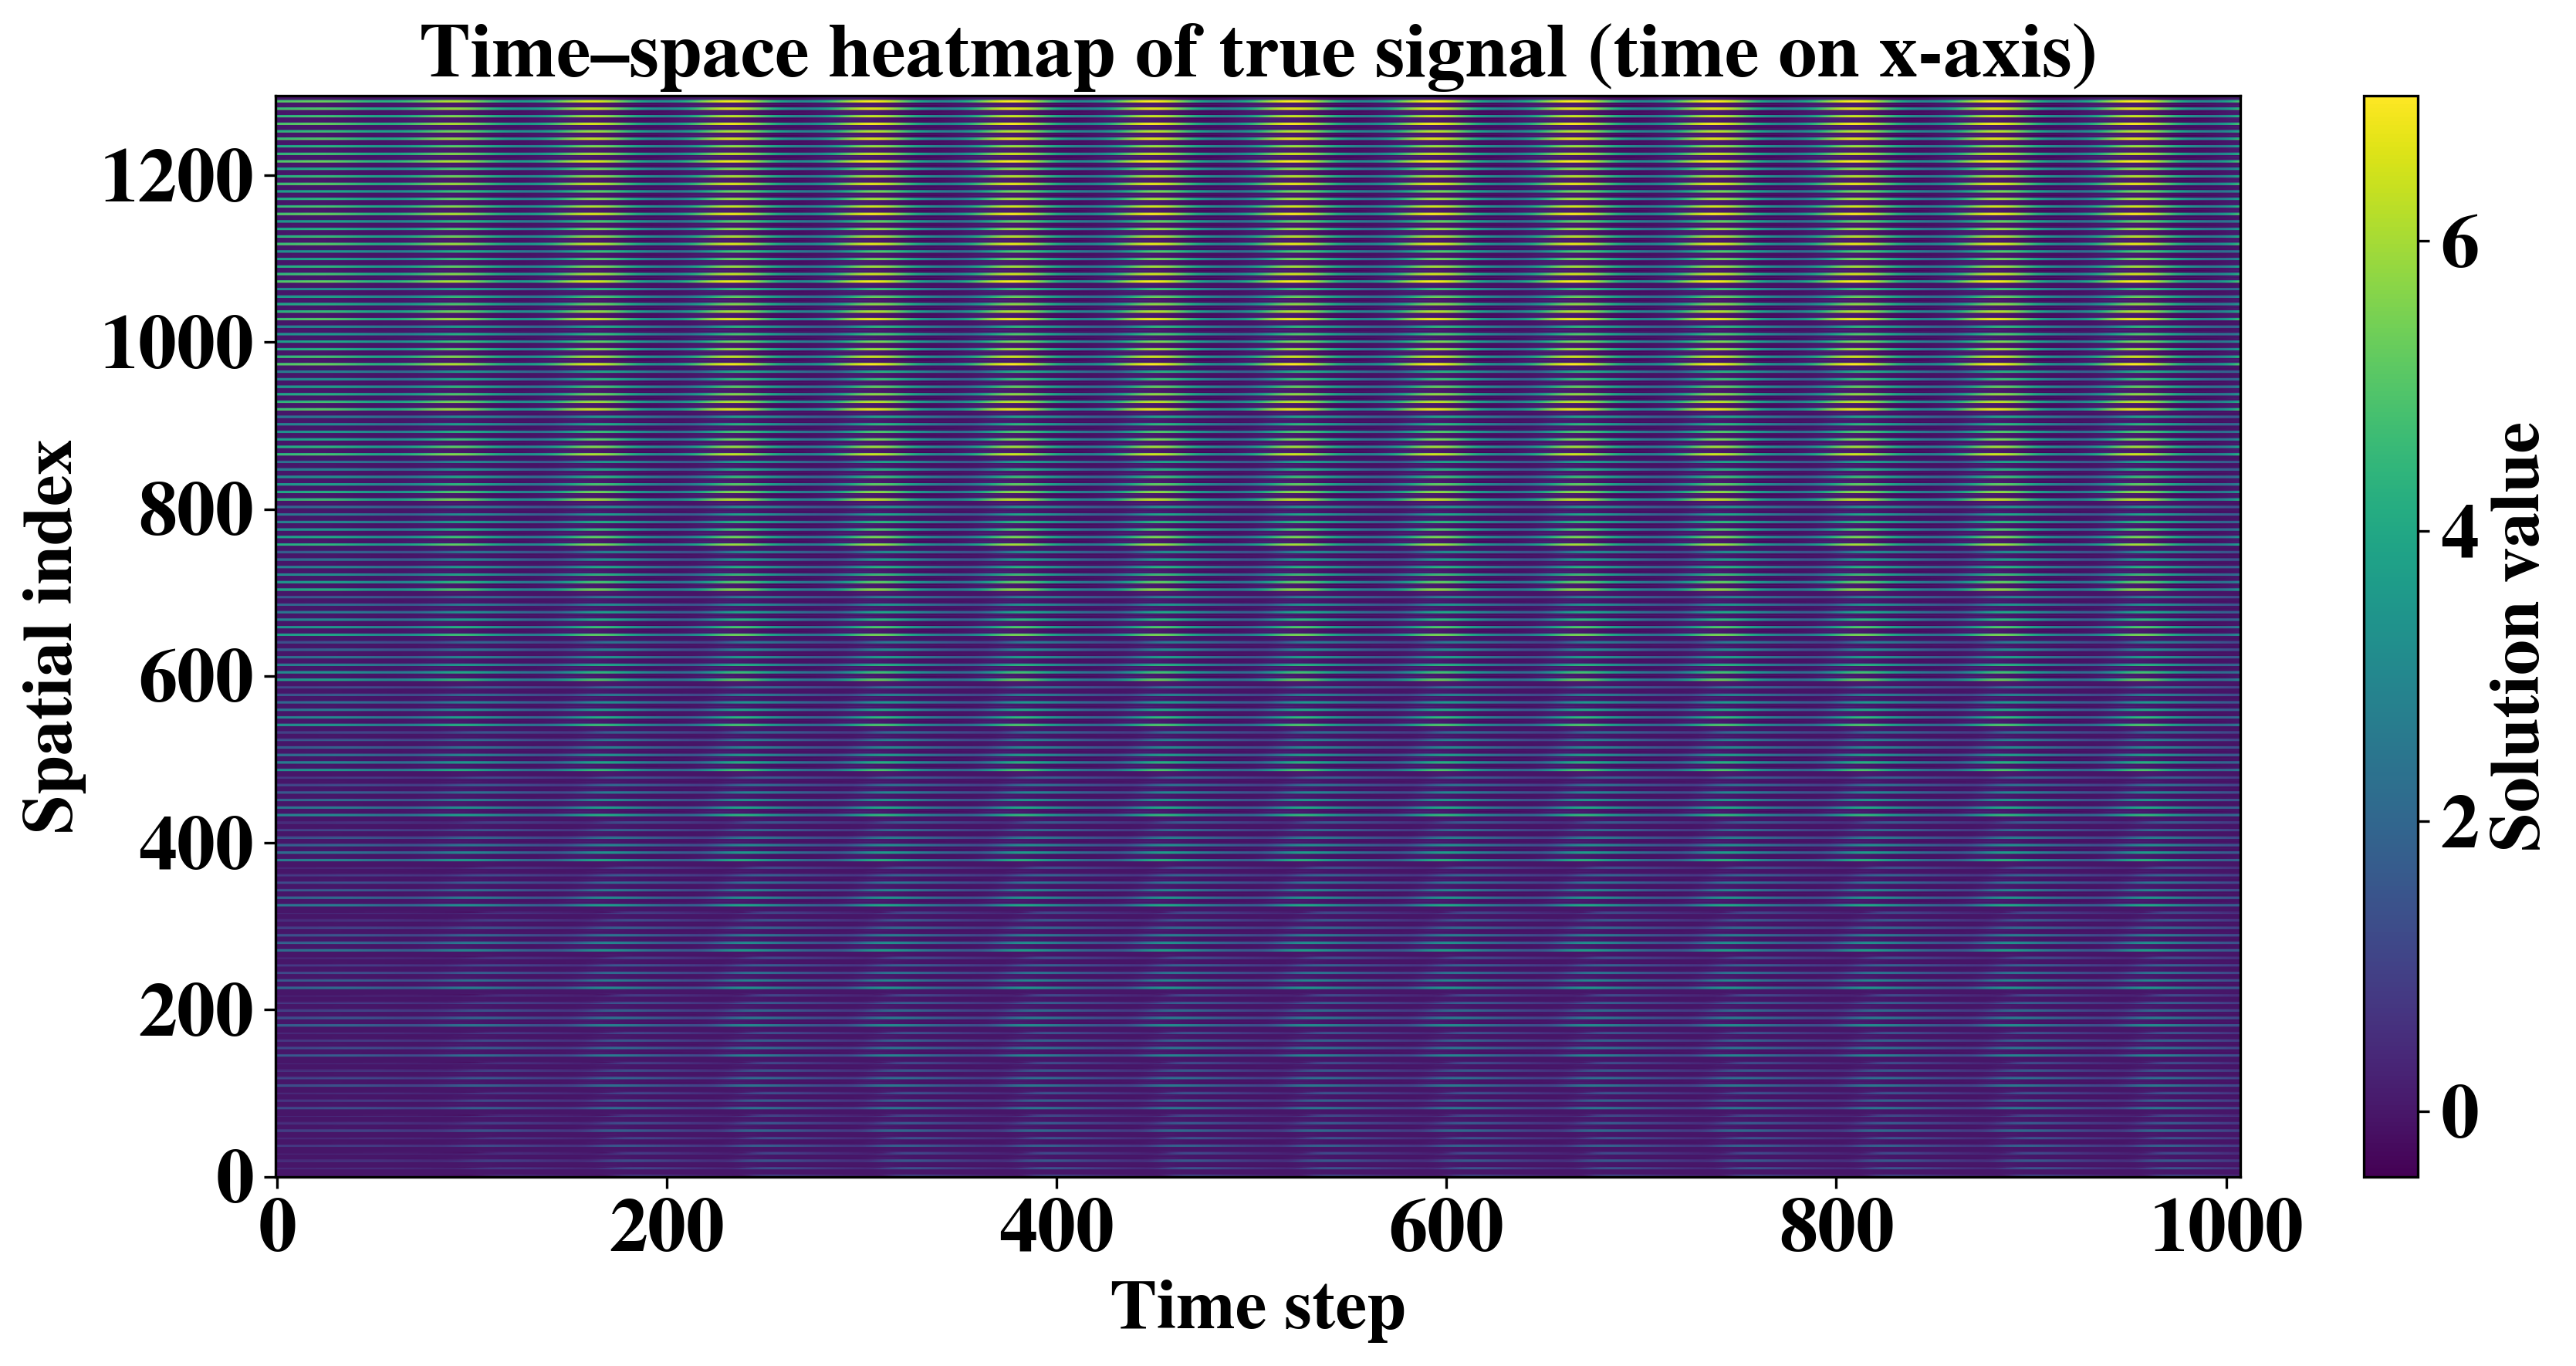

In [14]:

# # Plot 1: Time series at a single grid point (e.g., center point)
mid_idx = true_signal.shape[1] // 2
plt.figure(figsize=(10, 4))
plt.plot(true_signal[:, mid_idx], label=f"Grid point 1 {mid_idx}")
# plt.plot(true_signal2[:, mid_idx],label=f"Grid point 2 {mid_idx}")  # Add points for clarity
plt.xlabel("Time step")
plt.ylabel("Solution value")
plt.title("Time series at grid point")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Spatial average over time
spatial_mean = true_signal.mean(axis=1)
plt.figure(figsize=(10, 4))
plt.plot(spatial_mean, label="Spatial average")
plt.xlabel("Time step")
plt.ylabel("Average solution")
plt.title("Spatial average over time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Time–space heatmap with time on x-axis
plt.figure(figsize=(12, 6))
plt.imshow(true_signal.T, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label="Solution value")
plt.xlabel("Time step")
plt.ylabel("Spatial index")
plt.title("Time–space heatmap of true signal (time on x-axis)")
plt.tight_layout()
plt.show()



In [24]:

def build_observation_matrix(prob, V, obs_time_freq=2):
    num_cells = len(prob.mesh.geometry.dofmap)
    all_cells = np.arange(num_cells)
    obs_space_idx = np.arange(0, num_cells, obs_time_freq) # select every obs_time_freq-th cell for observation
    station_cells = all_cells[obs_space_idx]  # select cells for observation

    # Create observation matrix
    H = np.zeros((len(station_cells), V.dofmap.index_map.size_local))

    # pick subset of cells for the stations 
    station_coords = []

    # collapse the function space to get the coordinates of the dofs
    # in the cells that are selected for observation
    V_collapsed, indices_into_V = V.sub(0).collapse()   
    collapsed_dof_coords = V_collapsed.tabulate_dof_coordinates()
    indices_into_V = np.array(indices_into_V)

    for station, i in enumerate(station_cells):
        coords_for_cell = collapsed_dof_coords[V_collapsed.dofmap.cell_dofs(i)]
        dofs_in_orig_V = indices_into_V[V_collapsed.dofmap.cell_dofs(i)]
        H[station, dofs_in_orig_V] = 1/3 
        station_coord = 1/3 * (coords_for_cell.sum(axis=0))
        station_coords.append(station_coord)
        # print(f"Station {station} at {station_coord} corresponds to cell {i} with dofs {dofs_in_orig_V}")
    
    print(
        f"Total cells in mesh: {num_cells}\n"
        f"obs_time_freq: {obs_time_freq}\n"
        f"obs_space_idx: {obs_space_idx}\n"
        f"station_cells: {station_cells}\n"
        f"Number of observation stations: {len(station_cells)}"
    )

    
    
    return H, np.array(station_coords), obs_space_idx


def generate_observations(true_states, H, obs_time_idx, obs_std=0.1):
    # Extract only the states at the observation indices
    
    if isinstance(true_states, list):
        true_states = np.array(true_states)  # Ensure true_states is a numpy array
        
    observed_states = true_states[obs_time_idx]  # shape: (n_obs, state_dim)
    
    # Apply observation operator to all observed states at once
    y_n = observed_states @ H.T  # shape: (n_obs, obs_dim)

    # Add Gaussian noise
    noise = obs_std * np.random.randn(*y_n.shape)
    y_obs = y_n + noise

    return y_obs

def setup_observation_indices(window_size, obs_frequency, total_steps):
    """Setup observation indices for windows"""
    obs_indices_per_window = np.arange(0, window_size, obs_frequency)
    obs_indices = np.arange(0, total_steps - 1, obs_frequency)
    return obs_indices_per_window, obs_indices

In [25]:

# open true signal with pickle
with open(os.path.join('da_output','true_signal.pkl'), 'rb') as f:
    true_signal = pickle.load(f)

# problem_params['fric_law'] = 'mannings'  # Change friction law to mannings for this DA experiment
problem_params.update({'fric_law': 'mannings', 'dt': 900}) # Change friction law to mannings for this DA expirement

obs_std=0.4
obs_space_freq = 2
total_steps = int((problem_params['t_final']/problem_params['dt']) + 1)
problem_params['num_steps'] = int(np.ceil(final_time/problem_params['dt'])/problem_params['num_windows']) # Size of each assimilation window
obs_per_window = problem_params['num_steps'] // obs_time_freq

H, stations, obs_spatial_indices = build_observation_matrix(prob, prob.V, obs_space_freq)
obs_indices_per_window, obs_time_indices = setup_observation_indices(problem_params['num_steps'], obs_time_freq, total_steps)

# Create synthetic observations
y_obs = generate_observations(true_signal, H, obs_time_indices, obs_std)

print(f"\n Total Steps: {total_steps}\n"
      f"Total Assimilation Windows: {problem_params['num_windows']}\n"
      f"Steps per Window: {problem_params['num_steps']}\n"
      f"Obs Frequency: {obs_time_freq}\n"
      f"Total Obs: {obs_per_window * problem_params['num_windows']}\n"
      f"Number Stations: {stations.shape[0]}\n"
      f"Obs per Window: {obs_per_window}\n"
      )



# Generate Background,Observation, and Predicted Error Covariance Matrices
state_dim = true_signal.shape[1]
obs_dim = stations.shape[0]

# Observation Covariance 
R = np.eye(obs_dim) * (obs_std**2)

inflation_factor=2.0
B = inflation_factor*np.eye(state_dim) 

# Predicted Covariance
L = H @ B @ H.T 

# Get Inverse Covariance matrices
R_inv = np.linalg.inv(R)
B_inv = np.linalg.inv(B) 
L_inv = np.linalg.inv(L)

covs = {"B_inv": B_inv, "R_inv": R_inv, "L_inv": L_inv}

hb = 5.0 / 13800 * (13800 - stations[:, 0])

print(f"\nState Dimension: {state_dim}\n"
      f"Observation Dimension: {obs_dim}\n"
      f"Background Covariance Matrix Shape B: {B.shape}\n"
      f"Observation Covariance Matrix Shape R: {R.shape}\n"
      f"Predicted Error Covariance Matrix shape L: {L.shape}\n"
      f"Observation Matrix Shape H: {H.shape}\n",
      f"y_obs shape: {y_obs.shape}\n",
      f"Stations shape: {stations.shape}\n",
)


Total cells in mesh: 144
obs_time_freq: 2
obs_space_idx: [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142]
station_cells: [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142]
Number of observation stations: 72

 Total Steps: 673
Total Assimilation Windows: 42
Steps per Window: 16
Obs Frequency: 2
Total Obs: 336
Number Stations: 72
Obs per Window: 8


State Dimension: 1296
Observation Dimension: 72
Background Covariance Matrix Shape B: (1296, 1296)
Observation Covariance Matrix Shape R: (72, 72)
Predicted Error C

In [17]:
print(f"max:{H.max()}, "
      f"min: {H.min()}, "
      f"2-norm: {np.linalg.norm(H, ord=2)}, "
      f"cond #: {np.linalg.cond(H)}, "
      f"rank: {np.linalg.matrix_rank(H)}")

max:0.3333333333333333, min: 0.0, 2-norm: 0.5773502691896257, cond #: 1.0, rank: 72


In [26]:
bayes_analysis = run_assimilation(
                                  problem_params,
                                  solver_params,
                                  stations,
                                  y_obs,
                                  obs_per_window,
                                  obs_spatial_indices,
                                  obs_time_indices,
                                  H,
                                  covs,
                                  hb,
                                'sloped_beach',
                                cost_function_type='bayes'
                             )

Processing windows:   0%|          | 0/42 [00:00<?, ?window/s]

Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 0
Iteration 1: Cost = 302.514018

Optimization completed:
  Success: True
  Status: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Final cost: 3.025140e+02
  Iterations: 1
  Function evaluations: 4
  Gradient norm at solution: 1.289933e-05

------------------------------------------------------------

Solver Time 2: 0


Processing windows:   2%|▏         | 1/42 [00:02<01:51,  2.71s/window]

/////////////////////////////////////// Window 1 Completed ////////////////////////////////////////////////// 


Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 14400
Iteration 1: Cost = 345.060420
Iteration 2: Cost = 345.058491

Optimization completed:
  Success: True
  Status: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Final cost: 3.450585e+02
  Iterations: 2
  Function evaluations: 4
  Gradient norm at solution: 2.990967e-07

------------------------------------------------------------

Solver Time 2: 14400


Processing windows:   5%|▍         | 2/42 [00:05<01:59,  2.99s/window]

...

/////////////////////////////////////// Window 40 Completed ////////////////////////////////////////////////// 


Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 576000
Iteration 1: Cost = 1185.306393

Optimization completed:
  Success: True
  Status: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Final cost: 1.185306e+03
  Iterations: 1
  Function evaluations: 3
  Gradient norm at solution: 8.264170e-06

------------------------------------------------------------

Solver Time 2: 576000


Processing windows:  98%|█████████▊| 41/42 [07:52<00:09,  9.58s/window]

/////////////////////////////////////// Window 41 Completed ////////////////////////////////////////////////// 


Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 590400
Iteration 1: Cost = 2371.698103
Iteration 2: Cost = 2371.571318
Iteration 3: Cost = 2371.571318

Optimization completed:
  Success: True
  Status: 0
  Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  Final cost: 2.371571e+03
  Iterations: 3
  Function evaluations: 10
  Gradient norm at solution: 9.890844e-04

------------------------------------------------------------

Solver Time 2: 590400


Processing windows: 100%|██████████| 42/42 [08:14<00:00, 11.77s/window]

/////////////////////////////////////// Window 42 Completed ////////////////////////////////////////////////// 




In [27]:
# save bayes_analysis to a pickle file
with open(os.path.join('da_output','bayes_analysis.pkl'), 'wb') as f:
    pickle.dump(bayes_analysis, f)

In [ ]:
# get byes_analysis from the pickle file
with open(os.path.join('da_output','bayes_analysis.pkl'), 'rb') as f:
    bayes_analysis = pickle.load(f)

In [28]:
true_obs = H @ true_signal[obs_time_indices].T 
pred_obs = H @ bayes_analysis[obs_time_indices].T
bayes_rmse = np.sqrt(np.mean(true_signal - bayes_analysis) ** 2) # time averaged RMSE
bayes_misfit = np.linalg.norm(true_obs - pred_obs, ord=2)        # time averaged misfit
print(f"Bayes RMSE: {bayes_rmse:<.4f}, Bayes Misfit: {bayes_misfit:<.4f}")

Bayes RMSE: 0.0767, Bayes Misfit: 126.7292


In [30]:
true_signal.shape, bayes_analysis.shape

((672, 1296), (672, 1296))

In [ ]:
# dci_analysis = run_assimilation(
#                                   problem_params,
#                                   solver_params,
#                                   stations,
#                                   y_obs,
#                                   obs_per_window,
#                                   obs_spatial_indices,
#                                   obs_time_indices,
#                                   H,
#                                   covs,
#                                   hb,
#                                 'sloped_beach',
#                                 cost_function_type='dci'
#                              )

# true_states = np.array(true_signal.saved_states)
# Hu_true = (H @ true_states.T)  
# pred = dci_analysis[1:,:,0] + hb
# dci_height_misfit_rmse = np.sqrt(np.mean((Hu_true - pred.T) ** 2))
# print(f"DCI Analysis Height RMSE: {dci_height_misfit_rmse}")

In [ ]:
# dci_wme_analysis = run_assimilation(
#                                   problem_params,
#                                   solver_params,
#                                   stations,
#                                   y_obs,
#                                   obs_per_window,
#                                   obs_spatial_indices,
#                                   obs_time_indices,
#                                   H,
#                                   covs,
#                                   hb,
#                                 'sloped_beach',
#                                 cost_function_type='dci_wme'
#                              )

# true_states = np.array(true_signal.saved_states)
# Hu_true = (H @ true_states.T)  
# pred = dci_wme_analysis[1:,:,0] + hb
# dci_wme_height_misfit_rmse = np.sqrt(np.mean((Hu_true - pred.T) ** 2))
# print(f"DCI Analysis Height RMSE: {dci_wme_height_misfit_rmse}")

In [ ]:
plot_params = {
    "lines.linewidth": 8,
    "lines.markersize": 10,
    'lines.markeredgecolor': 'black',
    "legend.fontsize": 45,
    "legend.frameon": False,
    "xtick.labelsize": 45,
    "ytick.labelsize": 45,
    "axes.labelsize": 45,
    "axes.labelpad": 10,
    "axes.titlesize": 45,
    "figure.figsize": (44, 16),
}

station_idx = 10
with plt.rc_context(plot_params):
        plt.plot(true_obs[station_idx], linestyle="solid", label='True')
        plt.plot(pred_obs[station_idx], linestyle="dashed", label='Predicted')
        plt.legend(loc='upper left')
        plt.xlabel('Time Step')
        plt.ylabel('Water Height (m)')
        plt.title(f'Station {station_idx} Water Height Over Time')
        plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from dolfinx.fem import Function
from matplotlib import gridspec

def plot_mixed_function_matplotlib(msh, V, u_array, component=0, title="Mixed function component", 
                                    stations=None, cmap='viridis',
                                    show_mesh=True):
    """
    Matplotlib-based 2D visualization of a mixed function component from a raw array of coefficients,
    with full-height colorbar.
    """
    coords = msh.geometry.x[:, :2]

    # Collapse mixed space and extract subcomponent
    V_sub = V.sub(component)
    V_sub_c, sub_map = V_sub.collapse()

    u_sub = Function(V_sub_c)
    print(f"u_sub.x.array shape before assignment: {u_sub.x.array.shape}")
    print(f"Subcomponent map: {sub_map}")
    u_sub.x.array[:] = u_array[sub_map]
    print(f"u_sub.x.array shape: {u_sub.x.array.shape}")

    # Triangle mesh connectivity
    tdim = msh.topology.dim
    msh.topology.create_connectivity(tdim, 0)
    cells = msh.topology.connectivity(tdim, 0).array.reshape(-1, 3)

    # Interpolate function to mesh vertices
    dof_coords = V_sub_c.tabulate_dof_coordinates()[:, :2]
    dof_to_vertex_map = np.array([np.argmin(np.linalg.norm(dof_coords - x, axis=1)) for x in coords])
    values_at_vertices = u_sub.x.array[dof_to_vertex_map]

    triang = Triangulation(coords[:, 0], coords[:, 1], cells)

    # Set up figure with two columns: plot + colorbar
    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[20, 1], wspace=0.15)

    ax = fig.add_subplot(gs[0])
    cax = fig.add_subplot(gs[1])  # Colorbar axis

    # Main plot
    tpc = ax.tripcolor(triang, values_at_vertices, shading='gouraud', cmap=cmap)
    if show_mesh:
        ax.triplot(triang, color='white', linewidth=0.3, alpha=0.6)

    # ax.set_title(f"{title}")
    
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect('equal')

    # Stations
    if stations is not None:
        stations = np.asarray(stations)
        if stations.shape[1] == 3:
            stations = stations[:, :2]
        ax.plot(
                stations[:, 0],
                stations[:, 1],
                'o',                     # circular marker, no color shortcut
                markersize=5,
                color='red',             # fill color
                markeredgecolor='black', # edge color
                label="Stations"
            )
        # ax.legend()

    # Full-height colorbar
    cbar = fig.colorbar(tpc, cax=cax, shrink=0.5, aspect=15)
    cbar.set_label("Height (m)", fontsize=20)

    plt.tight_layout()
    plt.show()



def plot_comparison_matplotlib(msh, V, u_array_list, component=0, titles=None, stations=None, cmap='viridis'):
    """
    Matplotlib-based side-by-side comparison of multiple mixed-space solutions from raw arrays.

    Parameters:
    - msh: dolfinx.mesh.Mesh
    - V: dolfinx.fem.FunctionSpace (mixed space)
    - u_array_list: list of np.ndarray (raw .x.array[:] values)
    - component: int, index of the subcomponent to plot
    - titles: list of titles for each subplot
    - stations: optional Nx3 or Nx2 array of station coordinates
    - cmap: str, matplotlib colormap
    """
    n_plots = len(u_array_list)
    coords = msh.geometry.x[:, :2]

    # Mesh topology for triangulation
    tdim = msh.topology.dim
    msh.topology.create_connectivity(tdim, 0)
    cells = msh.topology.connectivity(tdim, 0).array.reshape(-1, 3)
    triang = Triangulation(coords[:, 0], coords[:, 1], cells)

    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), constrained_layout=True)
    if n_plots == 1:
        axes = [axes]

    for i, (u_array, ax) in enumerate(zip(u_array_list, axes)):
        V_sub = V.sub(component)
        V_sub_c, sub_map = V_sub.collapse()

        u_sub = Function(V_sub_c)
        u_sub.x.array[:] = u_array[sub_map]

        dof_coords = V_sub_c.tabulate_dof_coordinates()[:, :2]
        dof_to_vertex_map = np.array([np.argmin(np.linalg.norm(dof_coords - x, axis=1)) for x in coords])
        values_at_vertices = u_sub.x.array[dof_to_vertex_map]

        tpc = ax.tripcolor(triang, values_at_vertices, shading='gouraud', cmap=cmap)
        ax.triplot(triang, color='k', linewidth=0.3, alpha=0.5)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

        if titles and i < len(titles):
            ax.set_title(titles[i])
        else:
            ax.set_title(f"Solution {i + 1}")

        if stations is not None:
            stations = np.asarray(stations)
            if stations.shape[1] == 3:
                stations = stations[:, :2]
            ax.plot(stations[:, 0], stations[:, 1], 'ro', markersize=5)

    cbar = fig.colorbar(tpc, ax=axes, orientation='vertical', shrink=0.9)
    cbar.set_label("Height (m)", fontsize=20)

    plt.show()




u_sub.x.array shape: (432,)


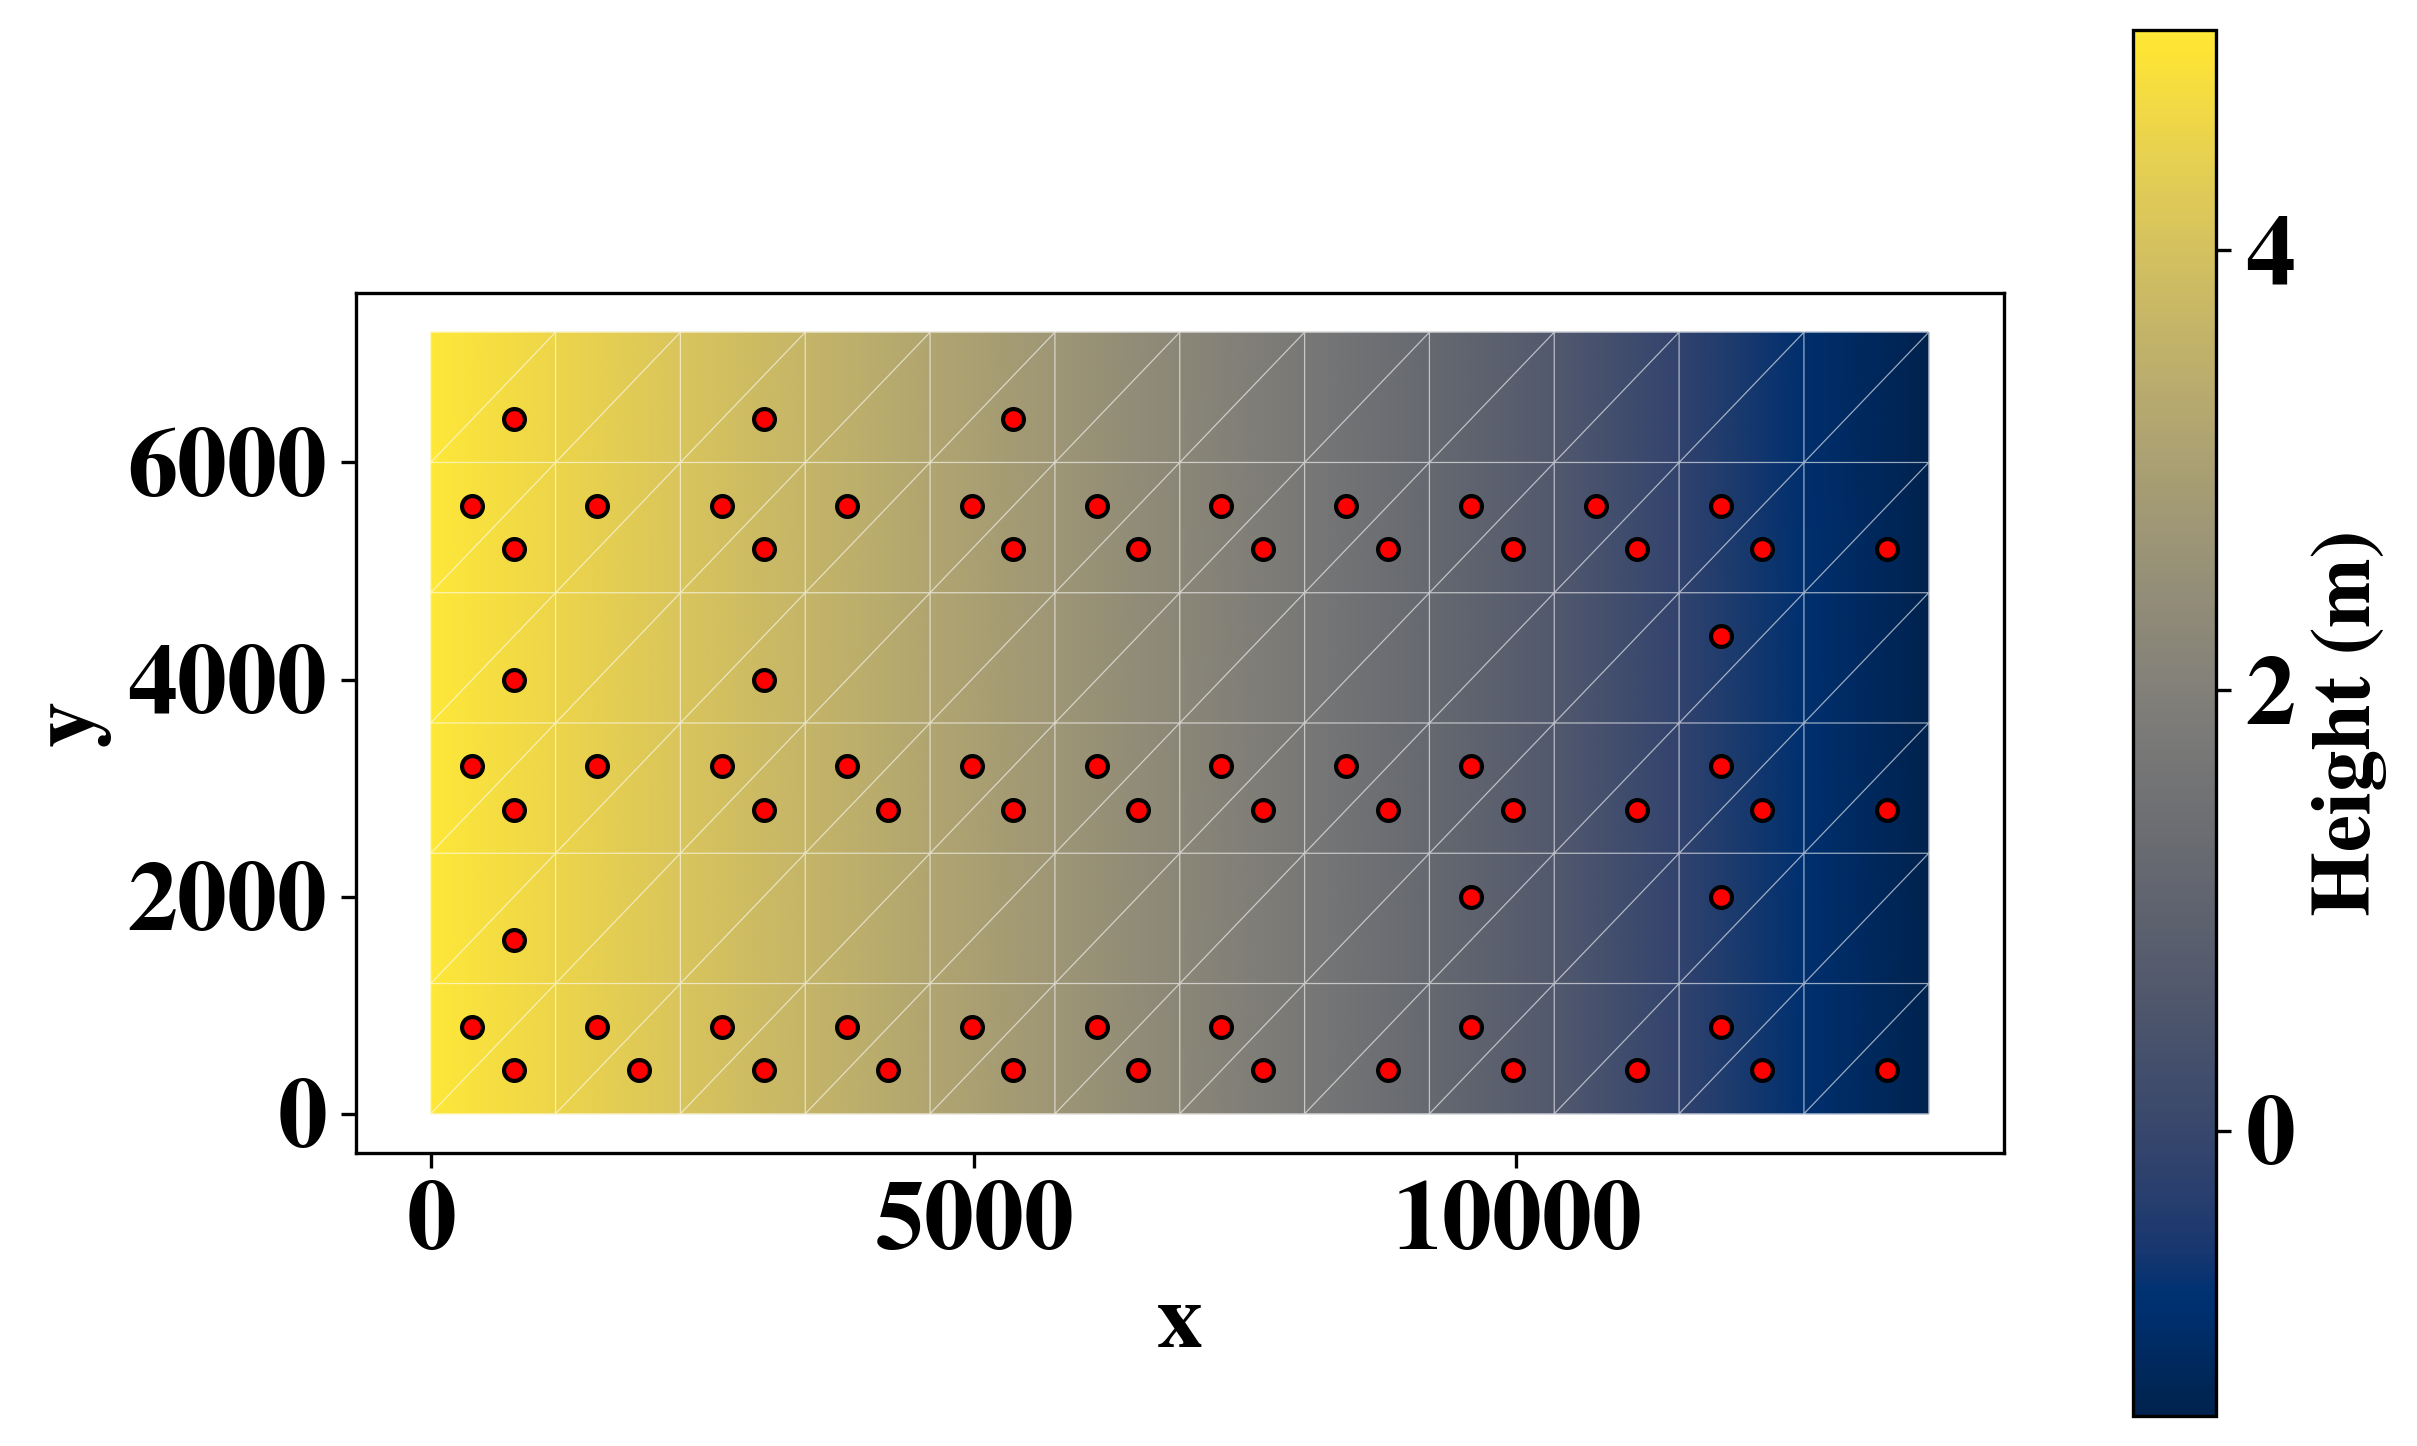

In [ ]:
plot_mixed_function_matplotlib(prob.mesh,
                    true_solver.V,
                    true_solver.u.x.array[:],
                    component=0,
                    title="Height",
                    stations=stations,
                    cmap='cividis',
                    )

In [37]:
true_signal.saved_states[0].shape, bayes_analysis.shape

((1296,), (1009, 72, 3))

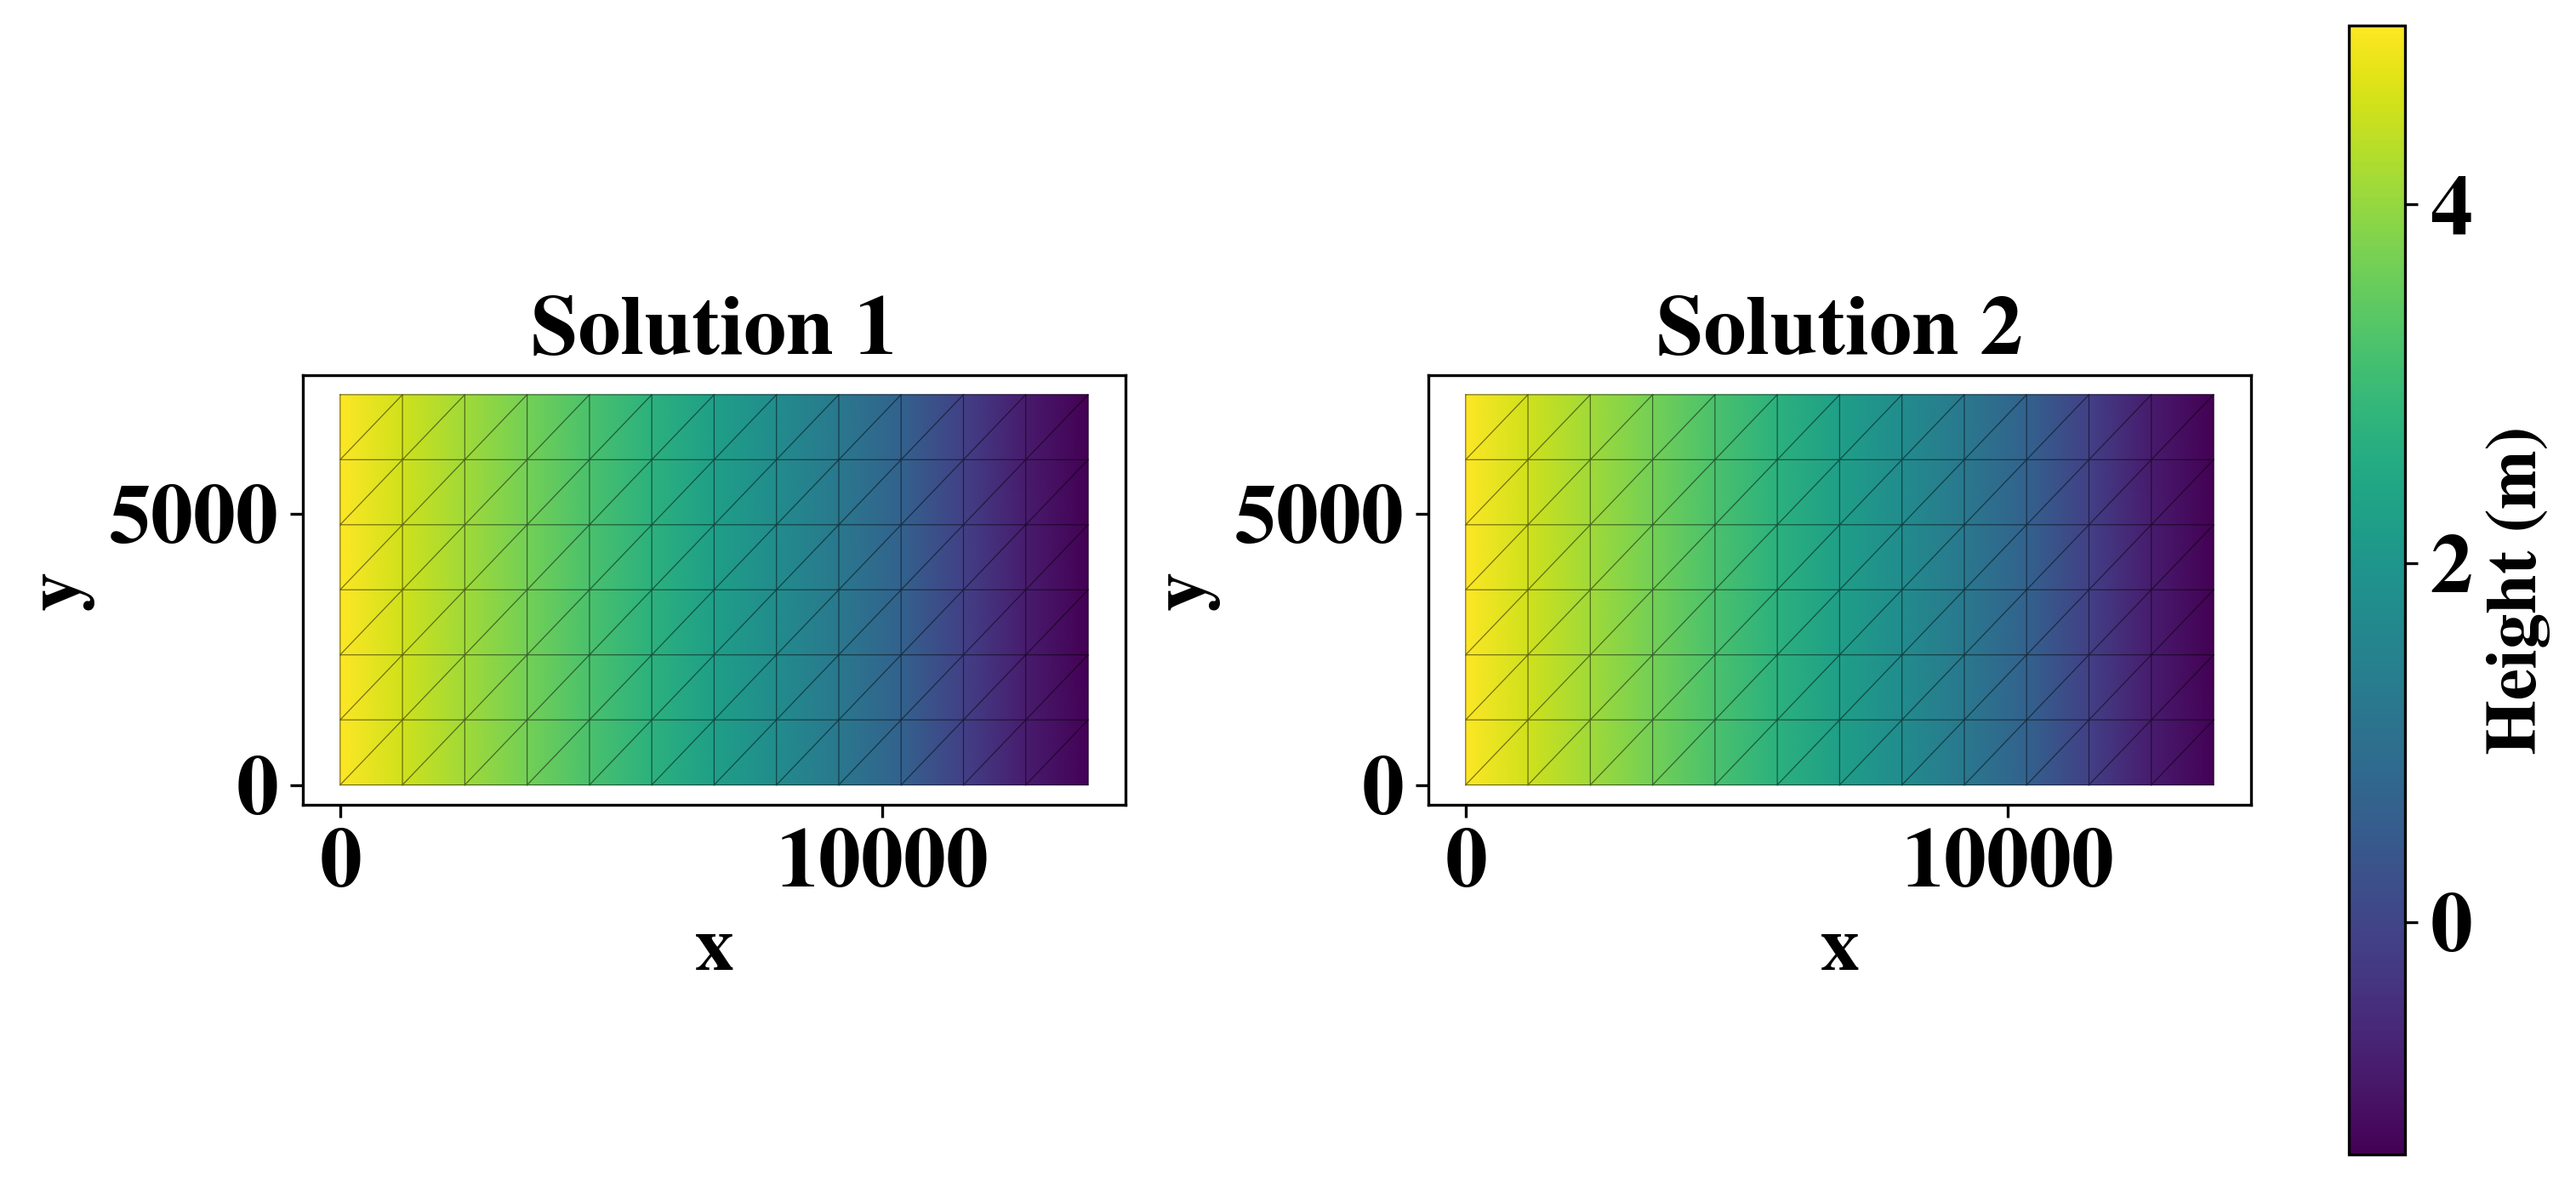

In [ ]:
u_list = [true_solver.u.x.array[:], true_solver.u.x.array[:]]  # Use the x.array[:] for both true and predicted states
plot_comparison_matplotlib(prob.mesh, true_solver.V, u_list, component=0, titles=None, stations=None, cmap='viridis')

# Scratch